# Exploratory Data Analysis

This notebook analyzes the conversation-level dataset created in the previous feature engineering step. The goal is to inspect data quality, understand the distributions of key prompt-level features and targets, and identify modelling-relevant patterns.

## Analysis Structure

The notebook is organized into the following sections:

1. Imports and configuration
2. Data loading
3. Feature groups
4. Data audit
5. Sanity checks
6. Numerical distributions
7. Categorical distributions
8. Target analysis
9. Topic analysis
10. EDA takeaways

## Focus

The analysis focuses primarily on prompt-level features that describe prompt length, instruction structure, task framing, and prompt quality. High-cardinality topic labels are analyzed separately to keep the notebook interpretable.

In [138]:
# ----------------------------
# IMPORTS + CONFIG
# ----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

PROJECT_ROOT = Path.cwd().parent

CONFIG = {
    "features_dir": PROJECT_ROOT / "01_data" / "03_features",
    "input_file": "llm_sustainability_strict_v1-1-0_dataframe.csv",
    "output_file": "llm_sustainability_strict_v1-2-0_dataframe.csv",
    "random_state": 42,
}

INPUT_PATH = CONFIG["features_dir"] / CONFIG["input_file"]
OUTPUT_PATH = CONFIG["features_dir"] / CONFIG["output_file"]

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_PATH:", OUTPUT_PATH)


INPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_dataframe.csv
OUTPUT_PATH: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv


In [139]:
# ----------------------------
# IO HELPERS
# ----------------------------

def load_csv(INPUT_PATH):
    with Path(INPUT_PATH).open("r", encoding="utf-8") as file:
        return pd.read_csv(file)

def save_csv(df, OUTPUT_PATH):
    path = Path(OUTPUT_PATH)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)


In [140]:
# ----------------------------
# LOAD DATA
# ----------------------------

df = load_csv(INPUT_PATH)

print("Input path:", INPUT_PATH)
print("Exists:", INPUT_PATH.exists())
print("Shape:", df.shape)

df.head()

Input path: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-1-0_dataframe.csv
Exists: True
Shape: (46429, 30)


,conversation_id,first_prompt,first_response,first_prompt_tokens,first_response_tokens,total_turns,interaction_rounds,total_user_prompts,followup_prompts,needs_follow_up,total_user_tokens,total_assistant_tokens,total_tokens,log_total_tokens,has_role_instruction,has_audience_or_level_instruction,has_format_instruction,question_count,prompt_style,task_type,orthographic_error_rate,is_valid_prompt,topic,topic_prob,topic_label,topic_cat,embedding_novelty,target_cost,target_success_refusal,target_needs_clarification
0,QWJhYvA,Summarize the main ideas of Jeff Walker's Product Launch Formula into bullet points as it pertains to a growth marke...,<div><p>Here are the main ideas of Jeff Walker's Product Launch Formula that can be applied by a growth marketing ag...,34,304,12,6.00,6,5,1,147,2034,2181,7.69,0,0,1,0,instruction,summarization,0.00,1,0,1.00,0_write_like_chatgpt_want_use,general,0.55,304,1,0
1,i6IyJda,How to tell if a customer segment is well segmented? In 3 bullet points.,"<div class=""markdown prose w-full break-words dark:prose-invert light""><ol><li><p>Homogeneity: The segment should co...",17,113,2,1.00,1,0,0,17,113,130,4.88,0,0,1,1,question,general_assistance,0.00,1,-1,0.52,-1_like_use_data_write_time,noise,0.78,113,1,0
2,A5AbcES,"In Java, I want to replace string like ""This is a new {object} at {place}"" with a Map, {object: ""student"", ""point 3,...","<div class=""markdown prose w-full break-words dark:prose-invert light""><p>You can use the <code>String.format()</cod...",62,1468,2,1.00,1,0,0,62,1468,1530,7.33,0,0,0,1,question,coding,0.00,1,-1,0.51,-1_like_use_data_write_time,noise,0.96,1468,1,0
3,hRPPgZT,Metaphorical language is also used to describe the various addressing modes of the instructions. Grandiose language ...,<div><p>Metaphorical language has been summoned to describe the many enigmatic addressing modes of the instructions ...,90,132,22,11.00,11,10,1,295,4979,5274,8.57,0,0,0,0,other,writing_generation,0.07,1,-1,0.76,-1_like_use_data_write_time,noise,0.73,132,1,0
4,KXxu9my,The following is the job of the hosting service team. Assign the roles and responsibilities of the person responsibl...,"<div class=""markdown prose w-full break-words dark:prose-invert light""><table><thead><tr><th>Role</th><th>Responsibi...",507,1014,10,5.00,5,4,1,861,19855,20716,9.94,0,0,0,0,other,coding,0.02,1,0,1.00,0_write_like_chatgpt_want_use,general,0.59,1014,1,0


In [141]:
df.columns

Index(['conversation_id', 'first_prompt', 'first_response',
       'first_prompt_tokens', 'first_response_tokens', 'total_turns',
       'interaction_rounds', 'total_user_prompts', 'followup_prompts',
       'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens',
       'total_tokens', 'log_total_tokens', 'has_role_instruction',
       'has_audience_or_level_instruction', 'has_format_instruction',
       'question_count', 'prompt_style', 'task_type',
       'orthographic_error_rate', 'is_valid_prompt', 'topic', 'topic_prob',
       'topic_label', 'topic_cat', 'embedding_novelty', 'target_cost',
       'target_success_refusal', 'target_needs_clarification'],
      dtype='str')

In [142]:
# ----------------------------
# FEATURE / TARGET SPLIT
# ----------------------------

FEATURE_COLUMNS = [
    "conversation_id",
    "first_prompt",
    "first_response",
    "first_prompt_tokens",
    "first_response_tokens",
    "total_turns",
    "interaction_rounds",
    "total_user_prompts",
    "needs_follow_up",
    "total_user_tokens",
    "total_assistant_tokens",
    "total_tokens",
    "log_total_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "is_valid_prompt",
    "topic",
    "topic_cat",
    "topic_prob",
    "topic_label",
    "embedding_novelty",
]

TARGET_COLUMNS = [
    "conversation_id",
    "target_cost",
    "target_success_refusal",
    "target_needs_clarification"
]

df_features = df[FEATURE_COLUMNS].copy()
df_target = df[TARGET_COLUMNS].copy()

In [143]:
# ----------------------------
# FEATURE GROUPS
# ----------------------------

central_features = [
    "first_prompt_tokens",
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "question_count",
    "prompt_style",
    "task_type",
    "orthographic_error_rate",
    "topic_prob",
    "topic_cat", 
    "embedding_novelty",
]

high_cardinality_features = [
    "topic_label",
]

target_features = [
    "target_cost",
    "target_success_refusal",
    "target_needs_clarification",
]

numeric_features = [
    "first_prompt_tokens",
    "question_count",
    "orthographic_error_rate",
    "target_cost",
    "topic_prob", 
    "embedding_novelty",
]

binary_features = [
    "has_role_instruction",
    "has_audience_or_level_instruction",
    "has_format_instruction",
    "target_success_refusal",
    "target_needs_clarification",
]

categorical_features = [
    "prompt_style",
    "task_type",
    "topic_cat",
]

id_text_columns = [
    "conversation_id",
    "first_prompt",
    "first_response",
]

print("Central features:", central_features)
print("High-cardinality features:", high_cardinality_features)
print("Target features:", target_features)

Central features: ['first_prompt_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'topic_prob', 'topic_cat', 'embedding_novelty']
High-cardinality features: ['topic_label']
Target features: ['target_cost', 'target_success_refusal', 'target_needs_clarification']


In [144]:
# ----------------------------
# DATA AUDIT
# ----------------------------

print("Rows, columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate conversation_id:", df["conversation_id"].duplicated().sum())

Rows, columns: (46429, 30)

Columns:
['conversation_id', 'first_prompt', 'first_response', 'first_prompt_tokens', 'first_response_tokens', 'total_turns', 'interaction_rounds', 'total_user_prompts', 'followup_prompts', 'needs_follow_up', 'total_user_tokens', 'total_assistant_tokens', 'total_tokens', 'log_total_tokens', 'has_role_instruction', 'has_audience_or_level_instruction', 'has_format_instruction', 'question_count', 'prompt_style', 'task_type', 'orthographic_error_rate', 'is_valid_prompt', 'topic', 'topic_prob', 'topic_label', 'topic_cat', 'embedding_novelty', 'target_cost', 'target_success_refusal', 'target_needs_clarification']

Data types:


conversation_id                          str
first_prompt                             str
first_response                           str
first_prompt_tokens                    int64
first_response_tokens                  int64
total_turns                            int64
interaction_rounds                   float64
total_user_prompts                     int64
followup_prompts                       int64
needs_follow_up                        int64
total_user_tokens                      int64
total_assistant_tokens                 int64
total_tokens                           int64
log_total_tokens                     float64
has_role_instruction                   int64
has_audience_or_level_instruction      int64
has_format_instruction                 int64
question_count                         int64
prompt_style                             str
task_type                                str
orthographic_error_rate              float64
is_valid_prompt                        int64
topic     


Missing values:


conversation_id                      0
first_prompt                         0
first_response                       0
first_prompt_tokens                  0
first_response_tokens                0
total_turns                          0
interaction_rounds                   0
total_user_prompts                   0
followup_prompts                     0
needs_follow_up                      0
total_user_tokens                    0
total_assistant_tokens               0
total_tokens                         0
log_total_tokens                     0
has_role_instruction                 0
has_audience_or_level_instruction    0
has_format_instruction               0
question_count                       0
prompt_style                         0
task_type                            0
orthographic_error_rate              0
is_valid_prompt                      0
topic                                0
topic_prob                           0
topic_label                          0
topic_cat                


Duplicate rows: 0
Duplicate conversation_id: 0


In [145]:
# ----------------------------
# SANITY CHECKS
# ----------------------------

print("Prompt style values:")
display(df["prompt_style"].value_counts(dropna=False))

print("\nTask type values:")
display(df["task_type"].value_counts(dropna=False).head(20))

print("\nTarget success values:")
display(df["target_success_refusal"].value_counts(dropna=False))
display(df["target_needs_clarification"].value_counts(dropna=False))

print("\nNumeric plausibility checks:")
display(
    df[
        [
            "first_prompt_tokens",
            "first_response_tokens",
            "total_turns",
            "question_count",
            "orthographic_error_rate",
            "target_cost",
        ]
    ].describe().T
)

Prompt style values:


prompt_style
other          22828
question       16310
instruction     7291
Name: count, dtype: int64


Task type values:


task_type
general_assistance    17587
writing_generation     9147
coding                 8231
explanation            4378
brainstorming          2056
email_writing          1452
translation            1322
summarization          1212
roleplay               1044
Name: count, dtype: int64


Target success values:


target_success_refusal
1    44518
0     1911
Name: count, dtype: int64

target_needs_clarification
0    39701
1     6728
Name: count, dtype: int64


Numeric plausibility checks:


,count,mean,std,min,25%,50%,75%,max
first_prompt_tokens,46429.00,196.71,877.41,2.00,21.00,44.00,136.00,79821.00
first_response_tokens,46429.00,498.08,925.64,1.00,161.00,337.00,583.00,76828.00
total_turns,46429.00,16.86,36.86,2.00,2.00,6.00,16.00,972.00
question_count,46429.00,0.63,3.25,0.00,0.00,0.00,1.00,261.00
orthographic_error_rate,46429.00,0.04,0.06,0.00,0.00,0.02,0.06,0.56
target_cost,46429.00,498.08,925.64,1.00,161.00,337.00,583.00,76828.00


## Numerical Distributions

This section explores the distributions of core numeric prompt-level features and the main cost target. The goal is to identify skewness, outliers, and scale differences that may matter for modelling.

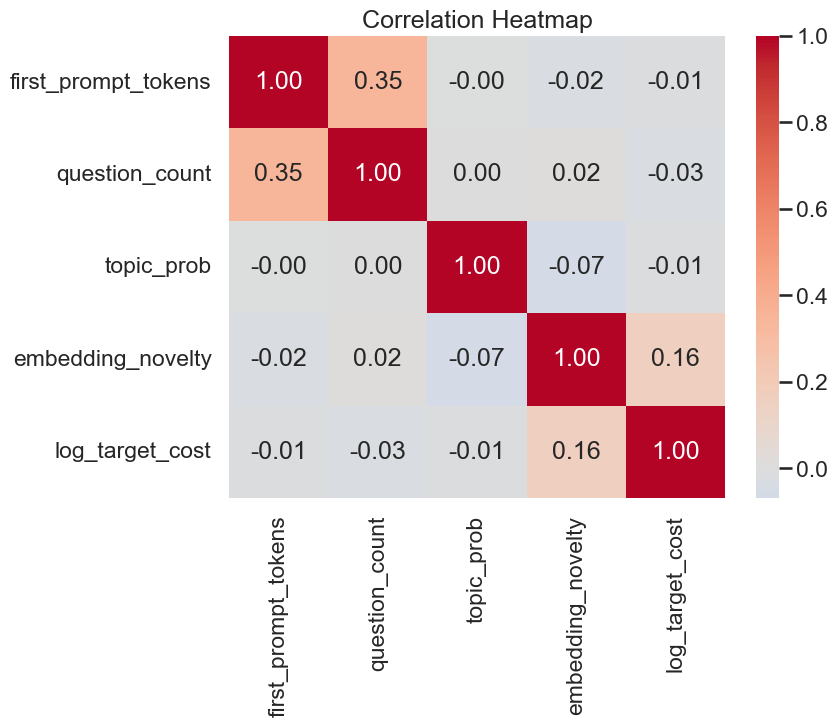

In [146]:
# ----------------------------
# CORRELATIONS
# ----------------------------

df["log_target_cost"] = np.log1p(df["target_cost"])


numeric_for_corr = [
    "first_prompt_tokens",
    "question_count",
#    "orthographic_error_rate",
    "topic_prob", 
    "embedding_novelty",
    "log_target_cost",
]

corr = df[numeric_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

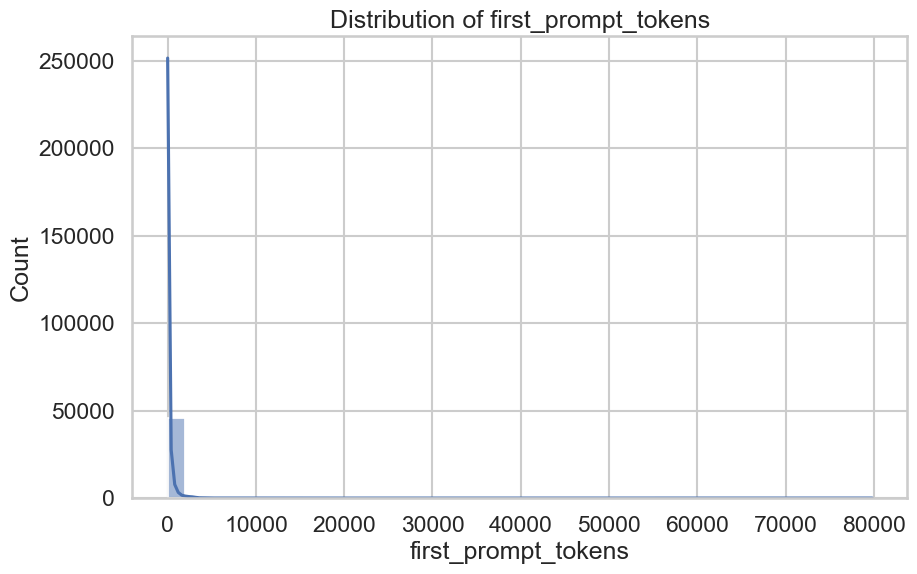

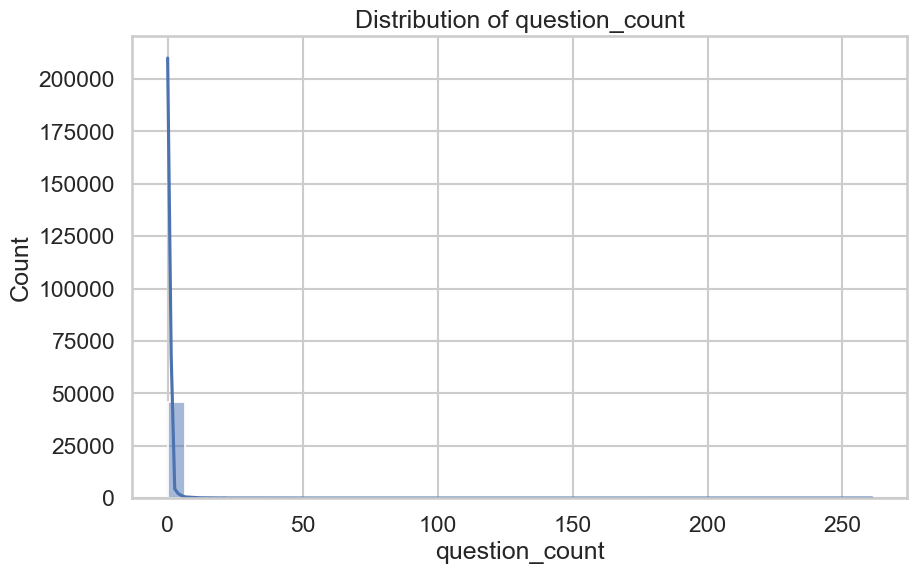

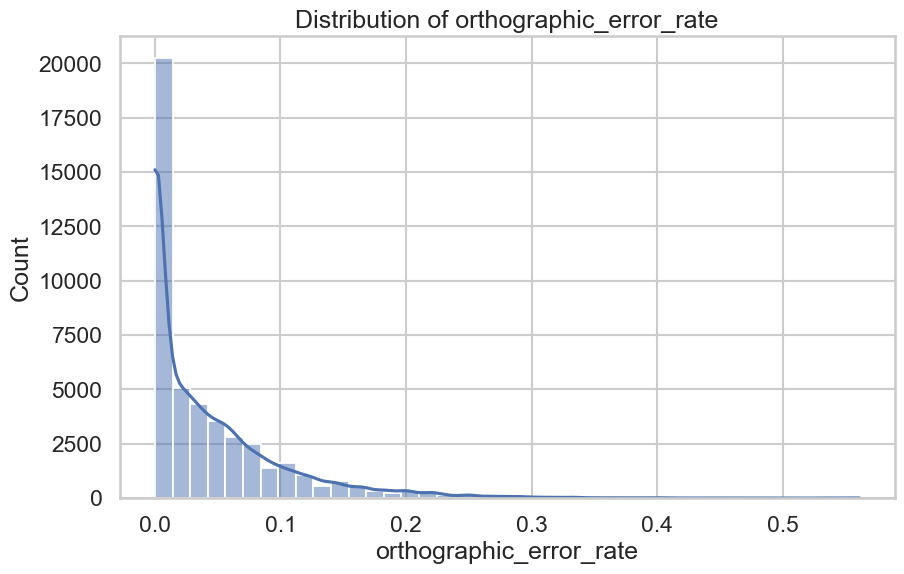

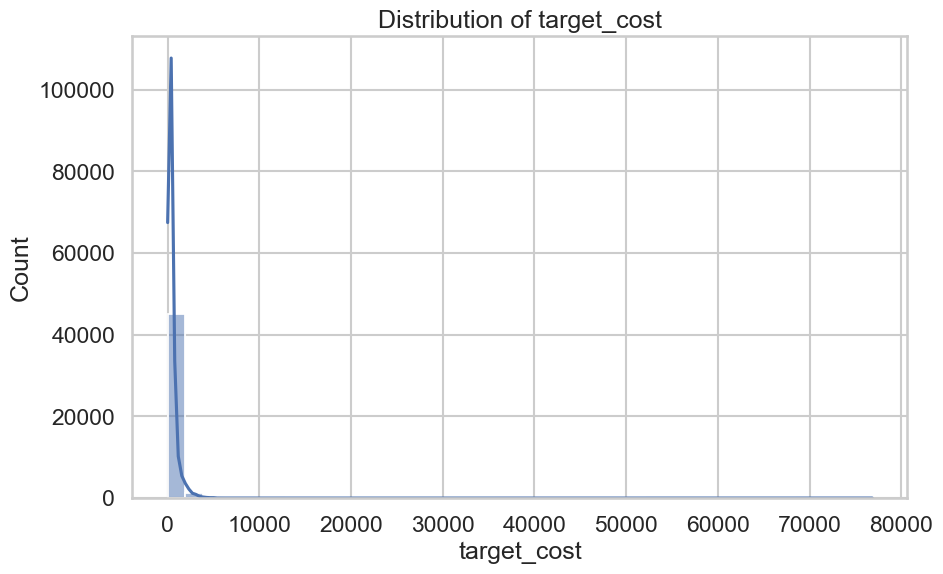

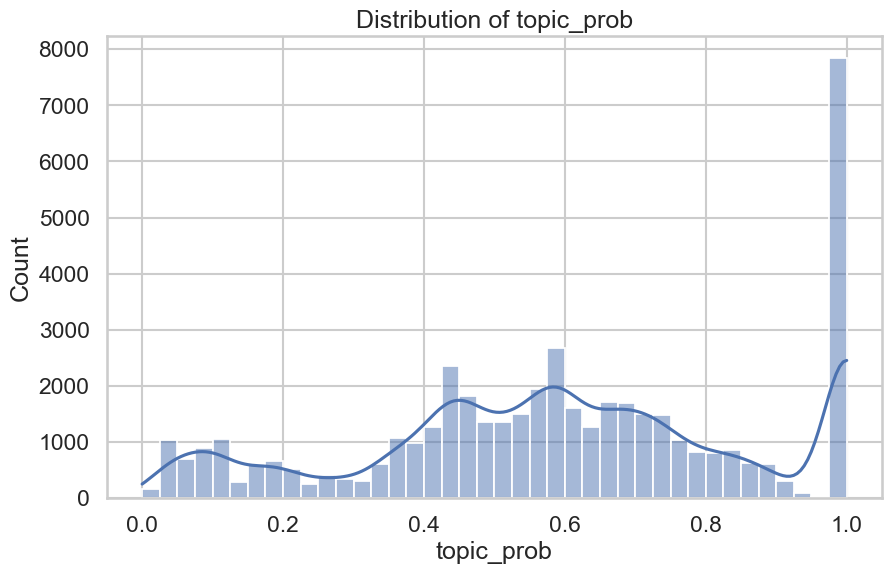

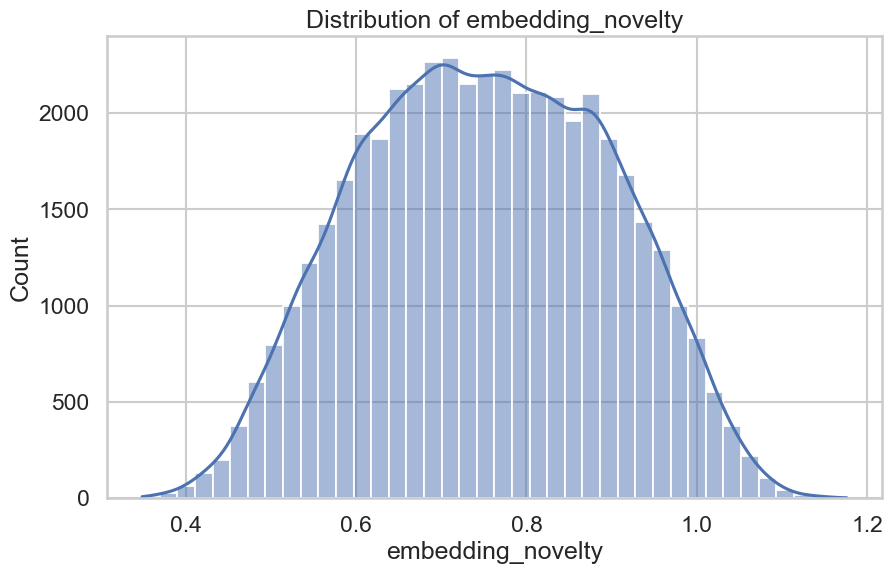

In [147]:
# ----------------------------
# NUMERICAL DISTRIBUTIONS
# ----------------------------

for col in numeric_features:
    plt.figure()
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

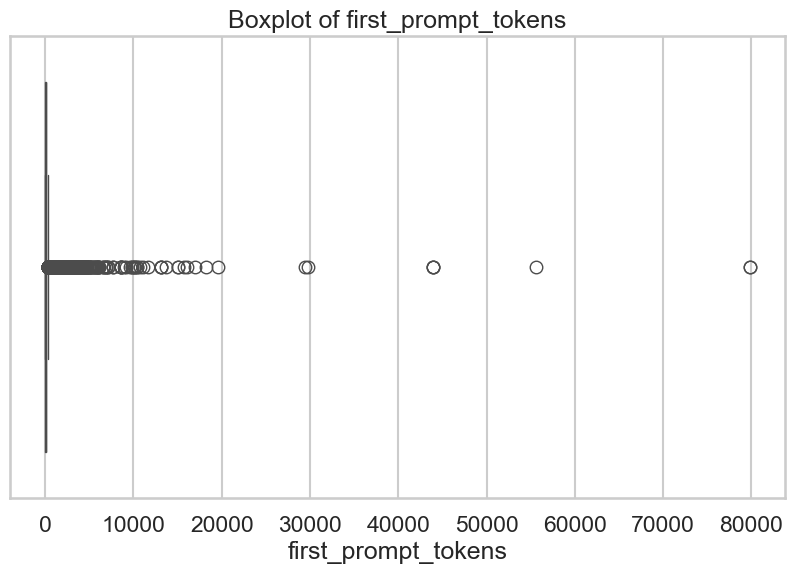

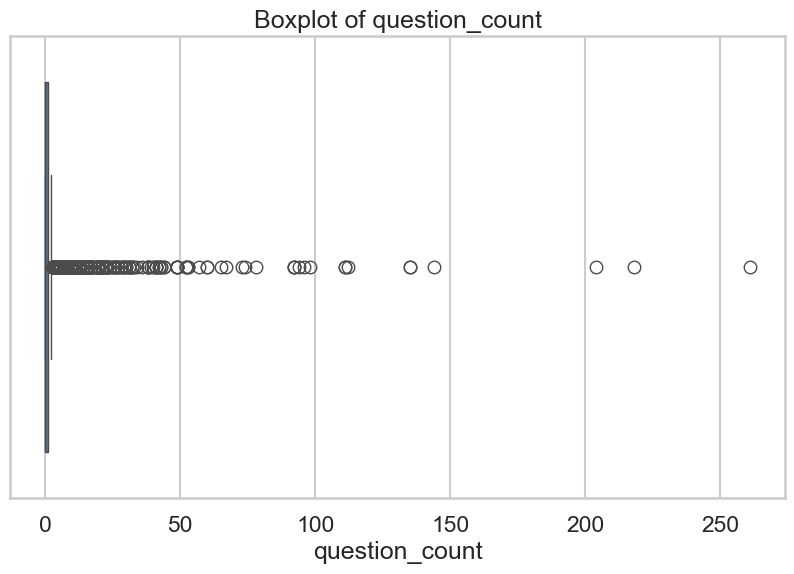

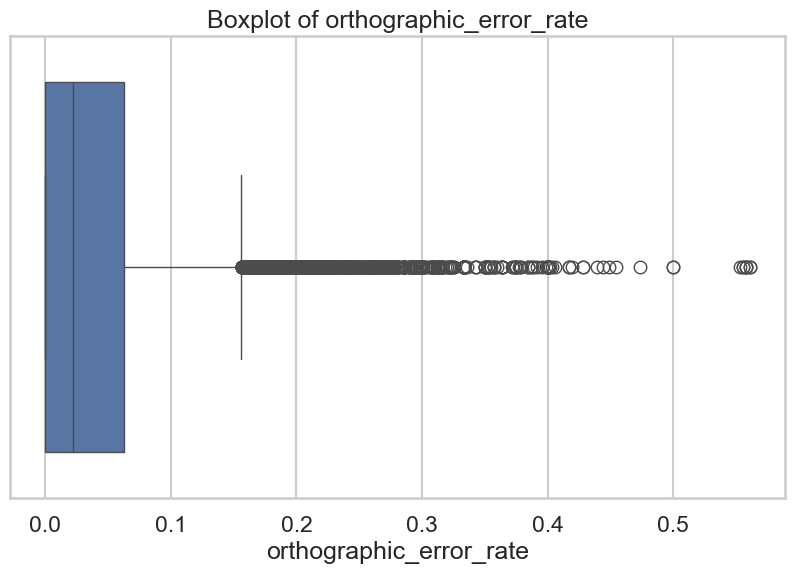

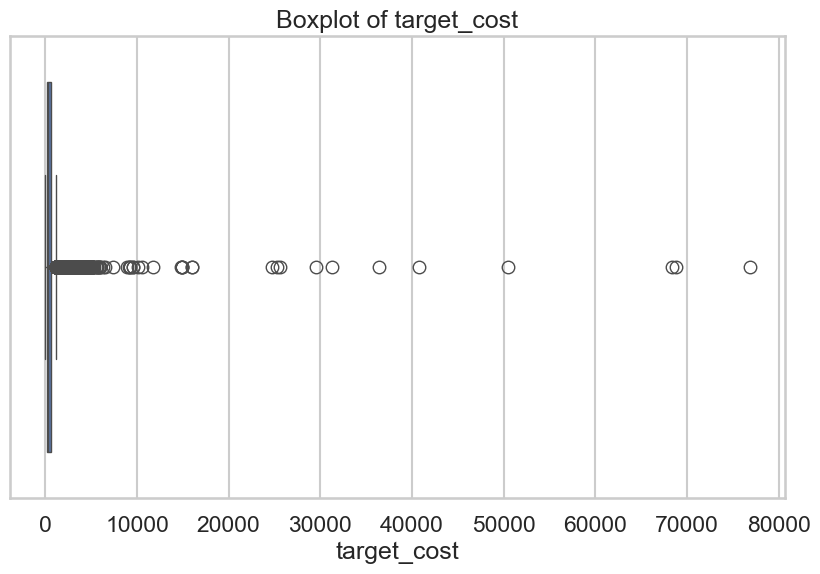

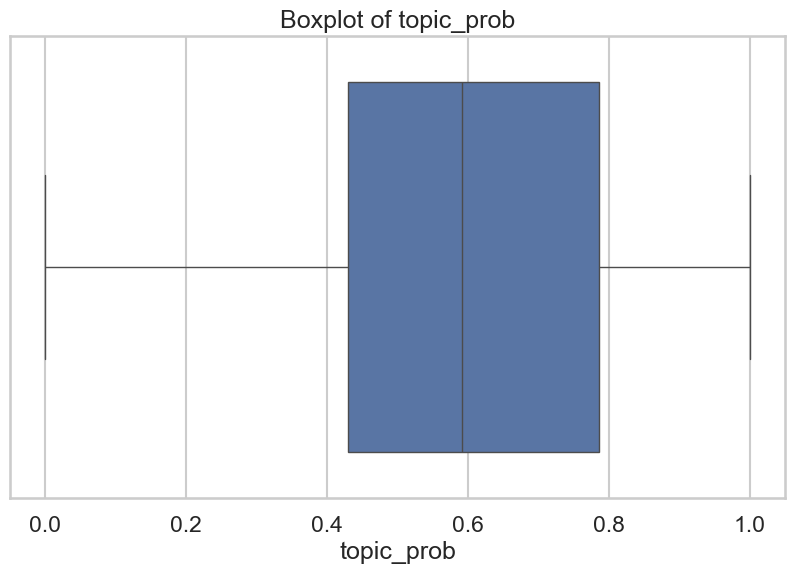

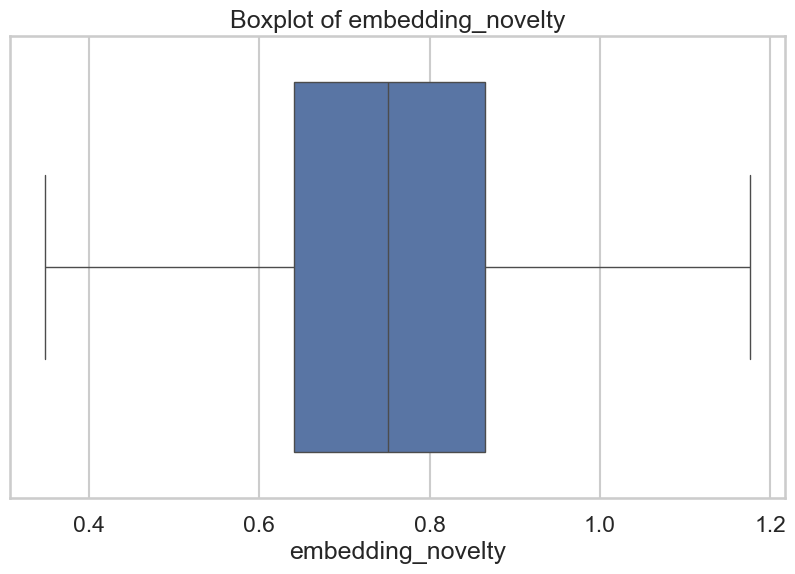

In [148]:
# ----------------------------
# NUMERICAL BOXPLOTS
# ----------------------------

for col in numeric_features:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## Categorical Distributions

This section summarizes the main binary and categorical prompt-level features. The goal is to understand how common different instruction styles, prompt styles, and task types are across the dataset.

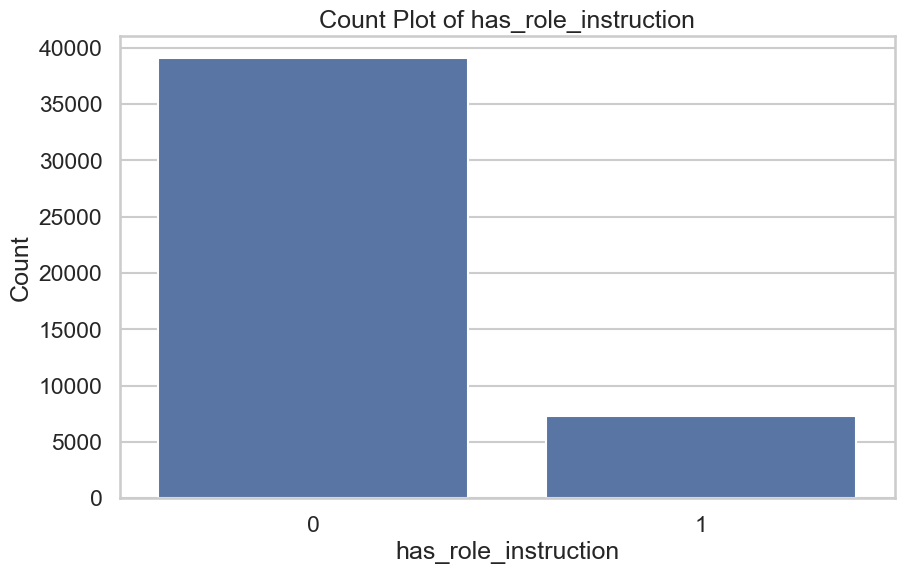

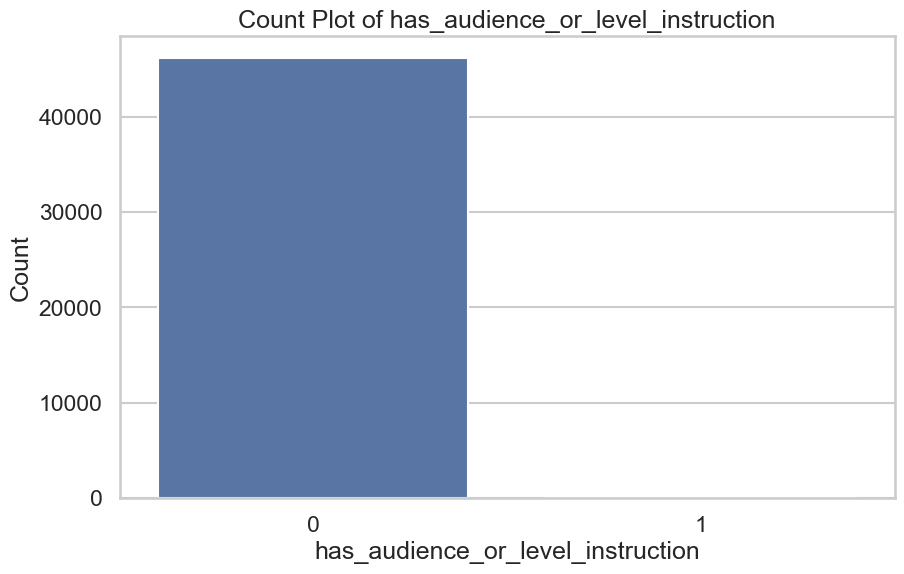

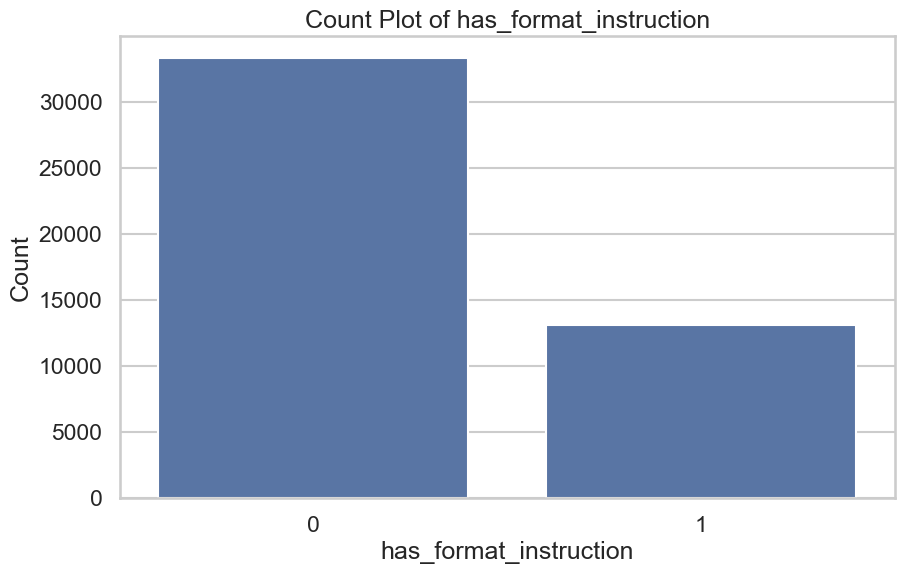

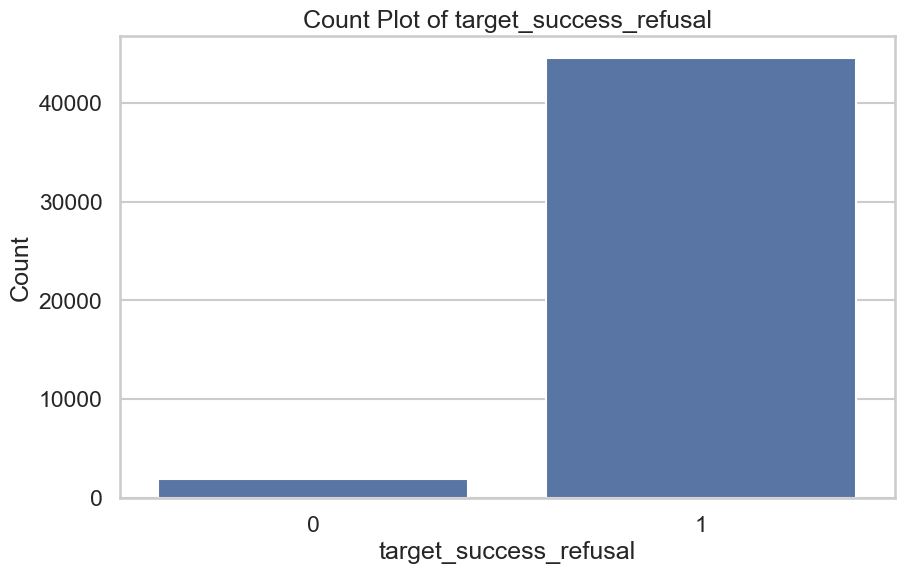

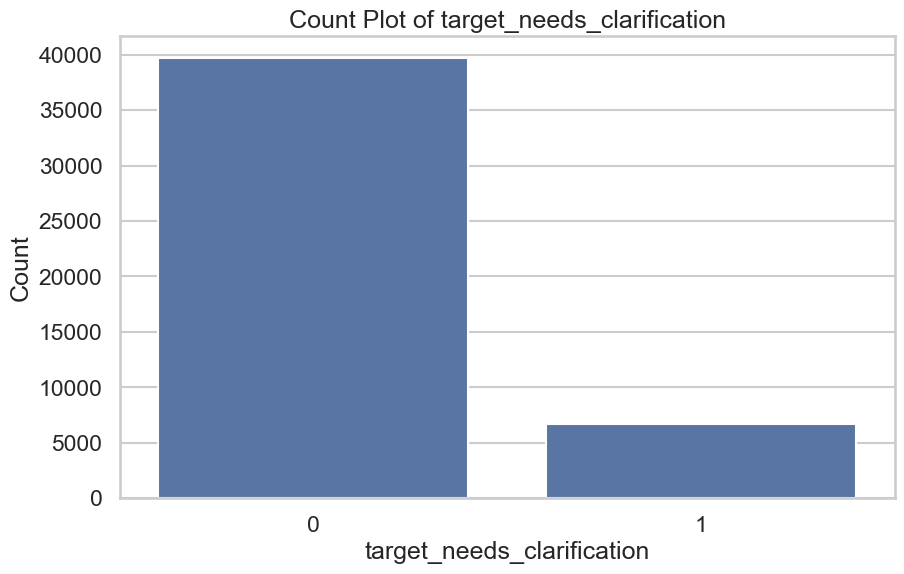

In [149]:
# ----------------------------
# BINARY FEATURES
# ----------------------------

for col in binary_features:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

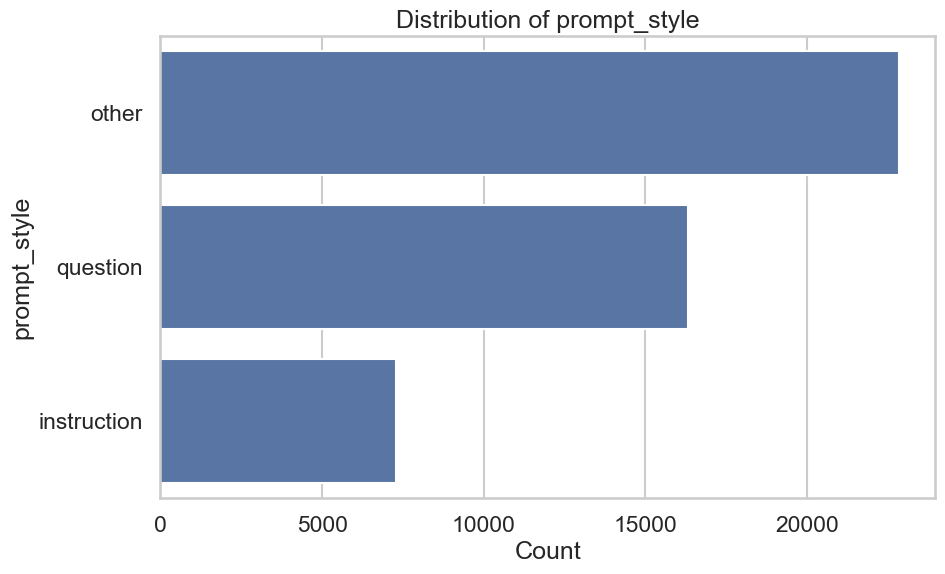

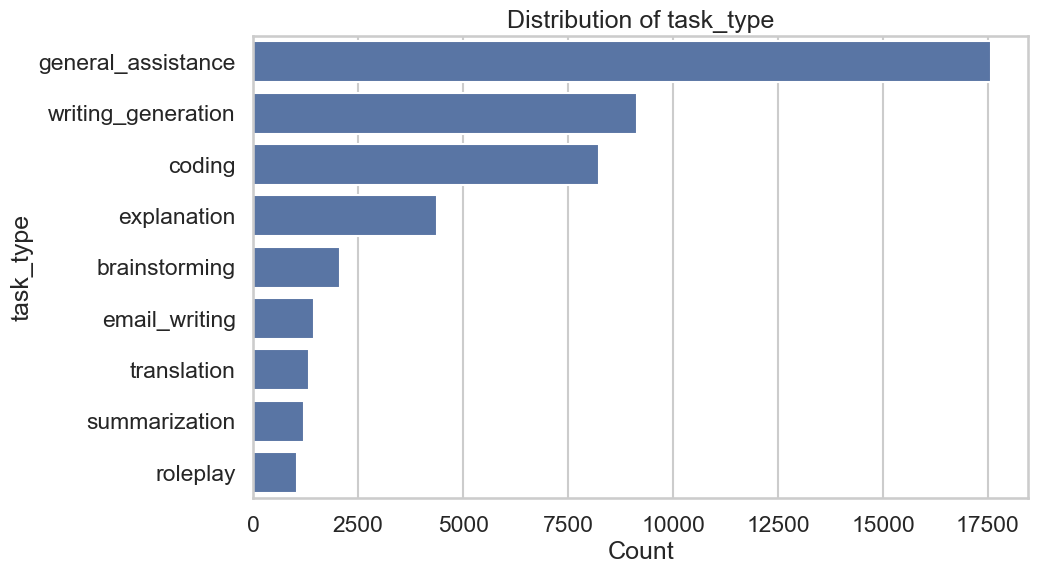

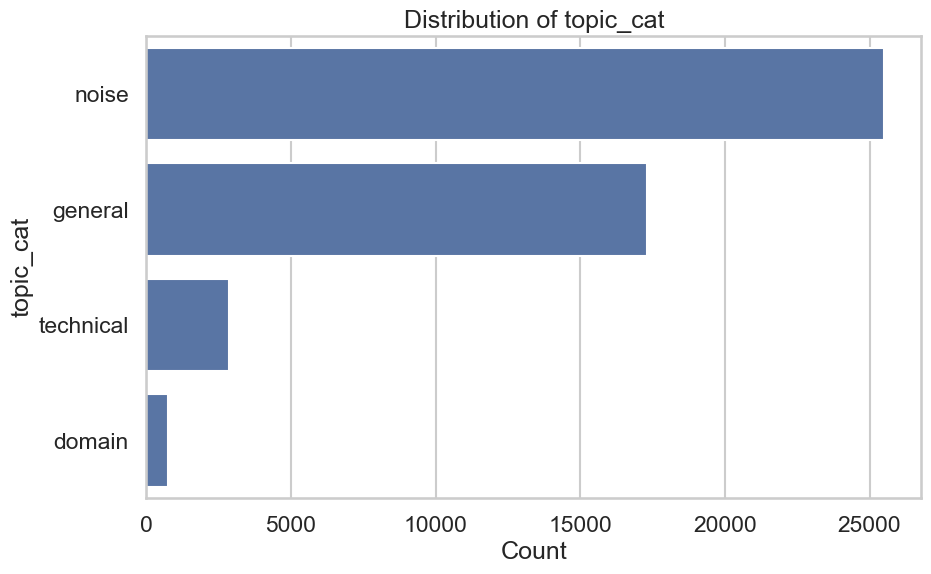

In [150]:
# ----------------------------
# CATEGORICAL FEATURES
# ----------------------------

for col in categorical_features:
    plt.figure(figsize=(10, 6))
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

## Target Analysis

This section examines the main modelling targets. The aim is to understand target balance, target skewness, and whether simple prompt-level features show visible relationships with cost and success.

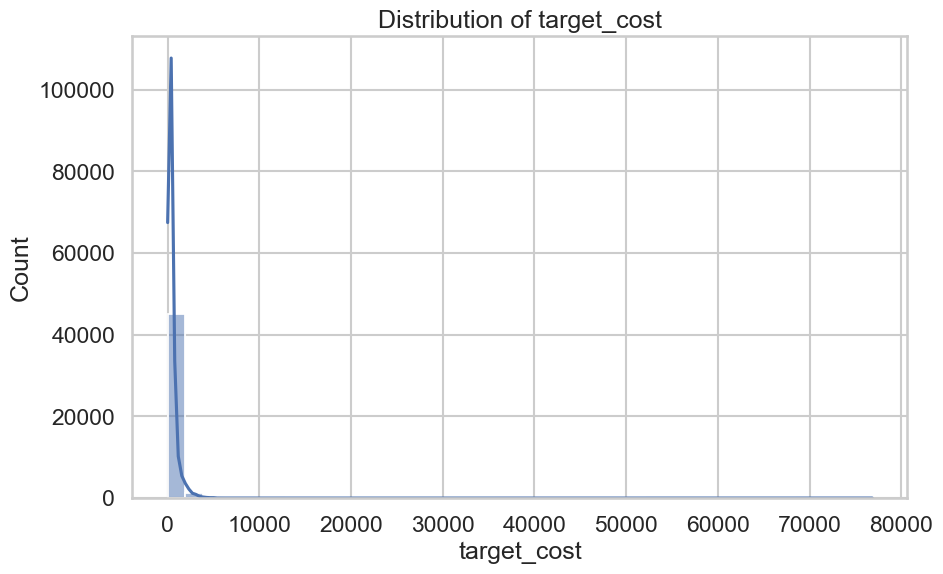

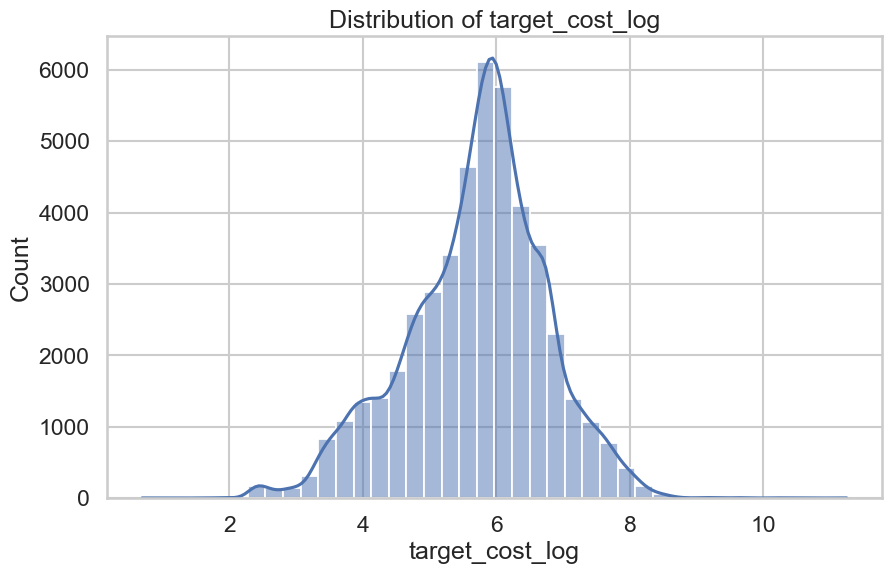

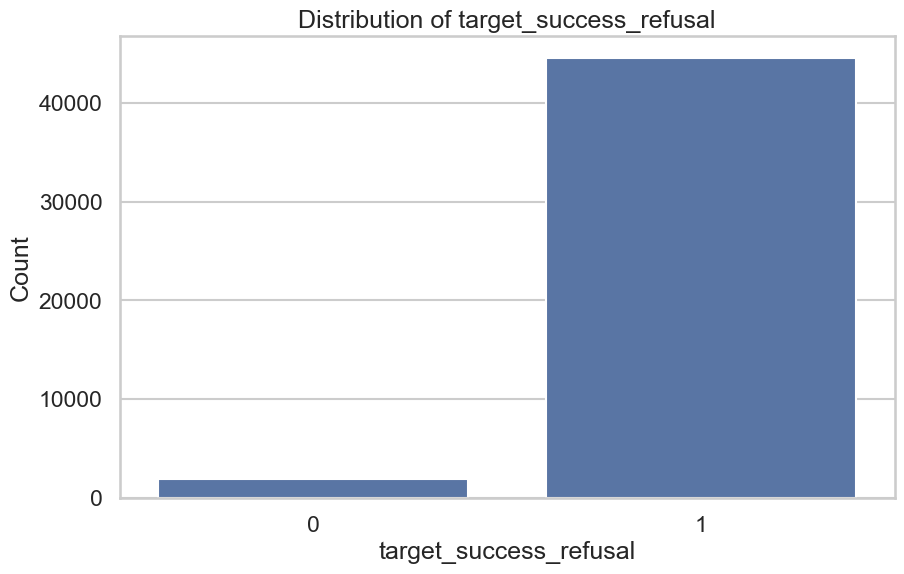

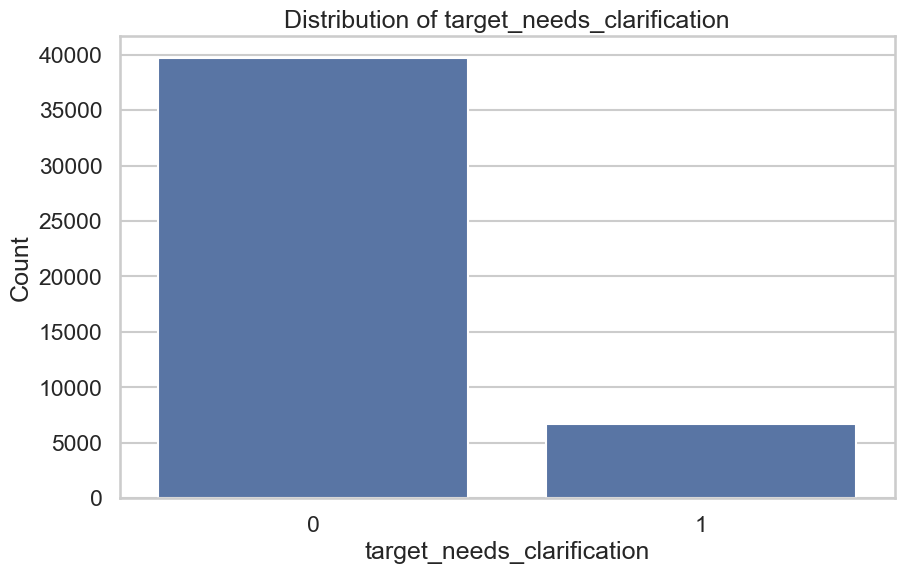

In [151]:
# ----------------------------
# TARGET DISTRIBUTIONS
# ----------------------------

plt.figure()
sns.histplot(df["target_cost"], bins=40, kde=True)
plt.title("Distribution of target_cost")
plt.xlabel("target_cost")
plt.ylabel("Count")
plt.show()


plt.figure()
sns.histplot(df["log_target_cost"], bins=40, kde=True)
plt.title("Distribution of target_cost_log")
plt.xlabel("target_cost_log")
plt.ylabel("Count")
plt.show()


plt.figure()
sns.countplot(x=df["target_success_refusal"])
plt.title("Distribution of target_success_refusal")
plt.xlabel("target_success_refusal")
plt.ylabel("Count")
plt.show()

plt.figure()
sns.countplot(x=df["target_needs_clarification"])
plt.title("Distribution of target_needs_clarification")
plt.xlabel("target_needs_clarification")
plt.ylabel("Count")
plt.show()




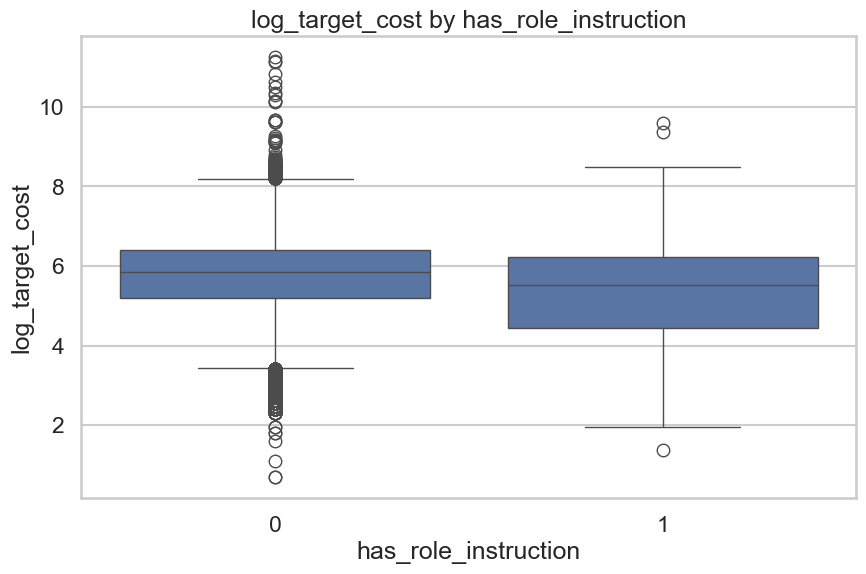

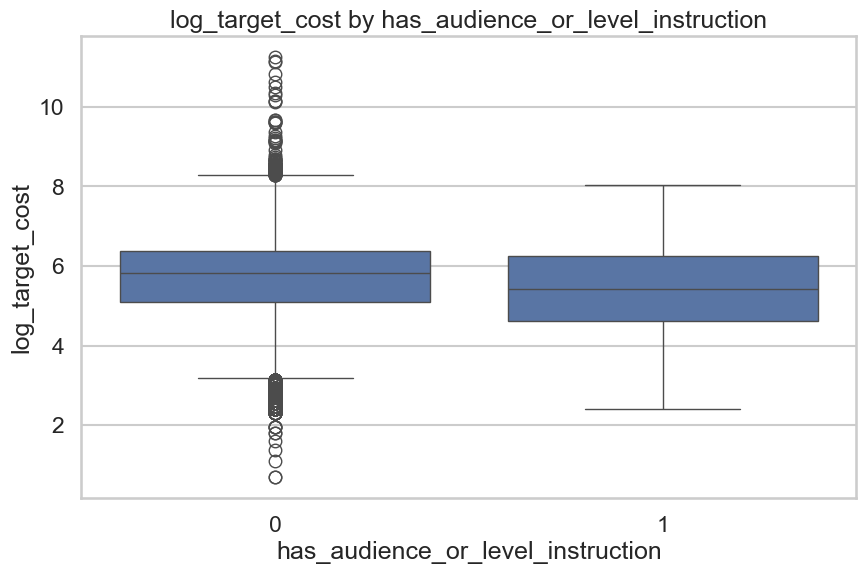

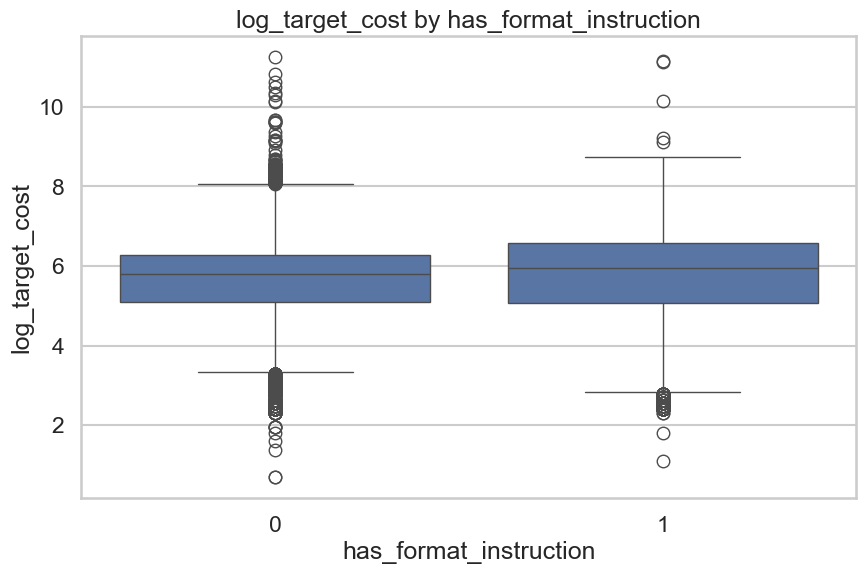

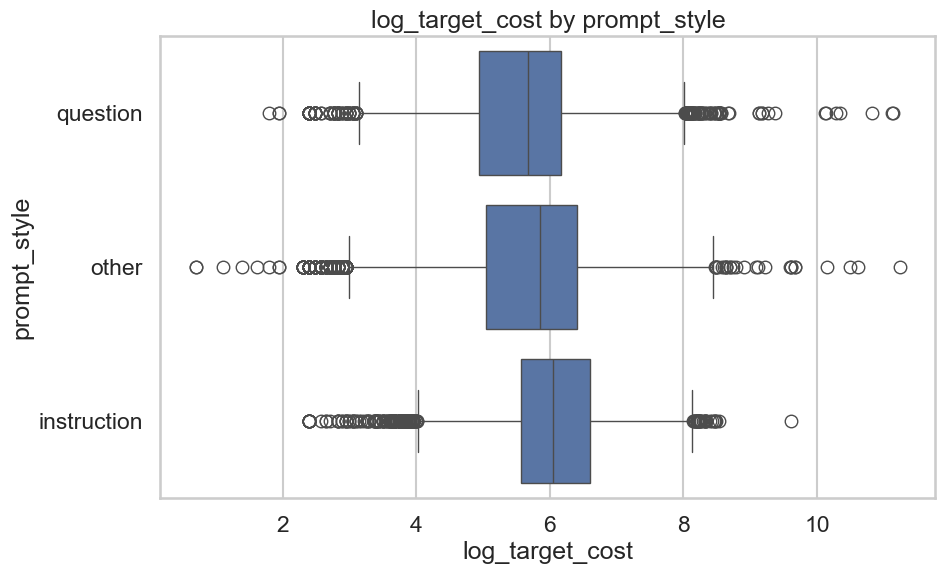

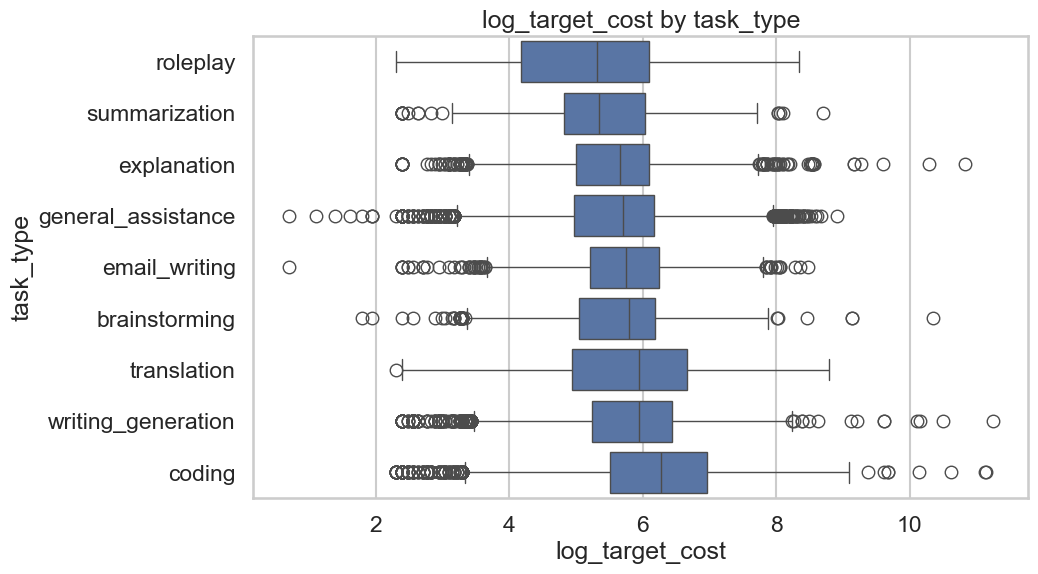

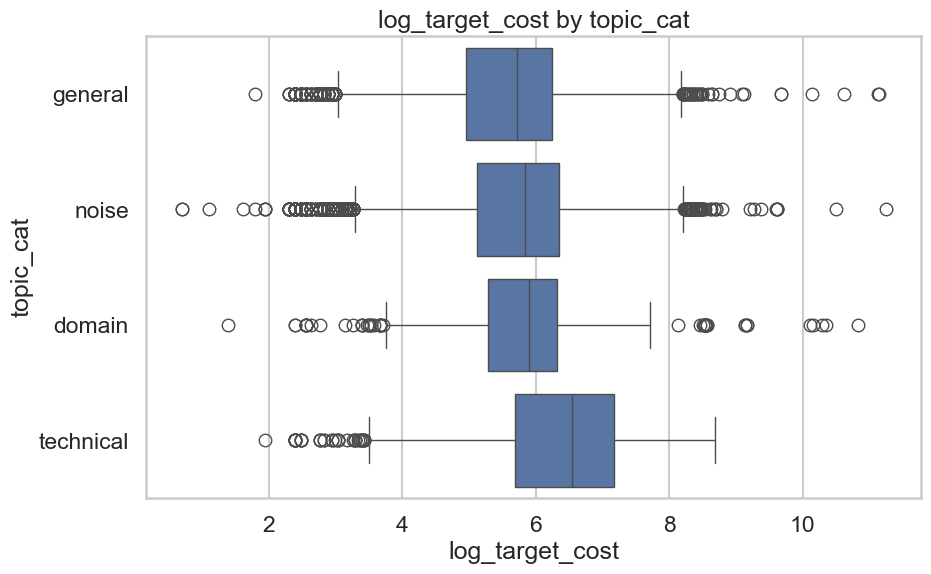

In [152]:
# ----------------------------
# TARGET VS CENTRAL FEATURES
# ----------------------------

for col in ["has_role_instruction", "has_audience_or_level_instruction", "has_format_instruction"]:
    plt.figure()
    sns.boxplot(data=df, x=col, y="log_target_cost")
    plt.title(f"log_target_cost by {col}")
    plt.show()

for col in ["prompt_style", "task_type", "topic_cat"]:
    plt.figure(figsize=(10, 6))
    order = df.groupby(col)["log_target_cost"].median().sort_values().index
    sns.boxplot(data=df, y=col, x="log_target_cost", order=order)
    plt.title(f"log_target_cost by {col}")
    plt.show()

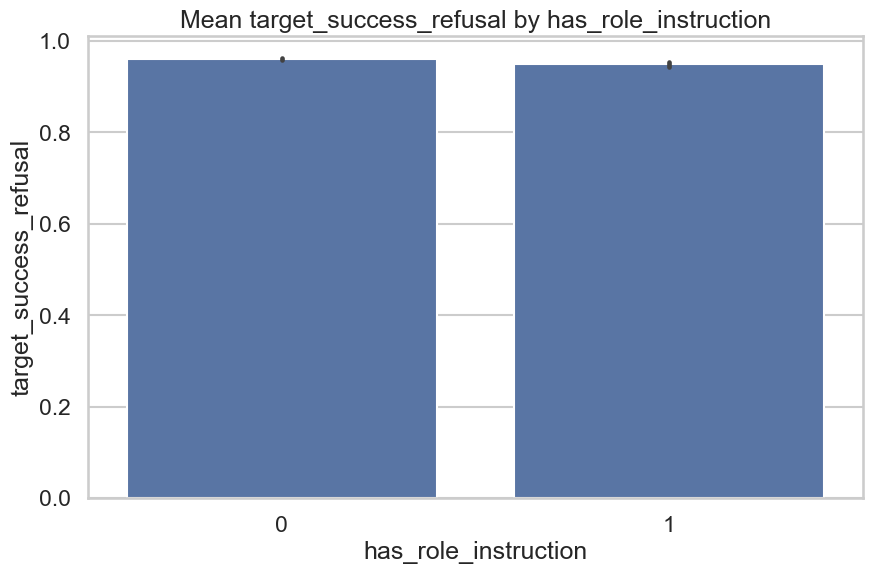

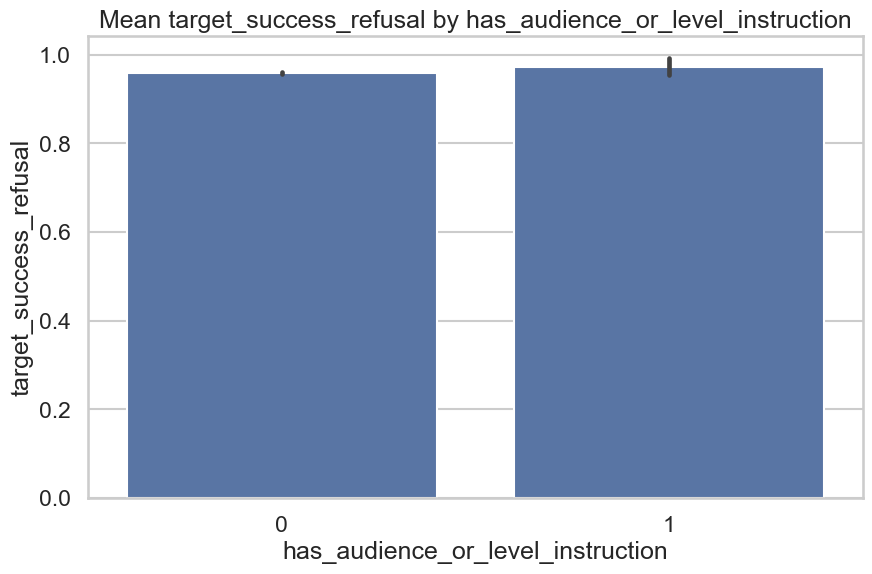

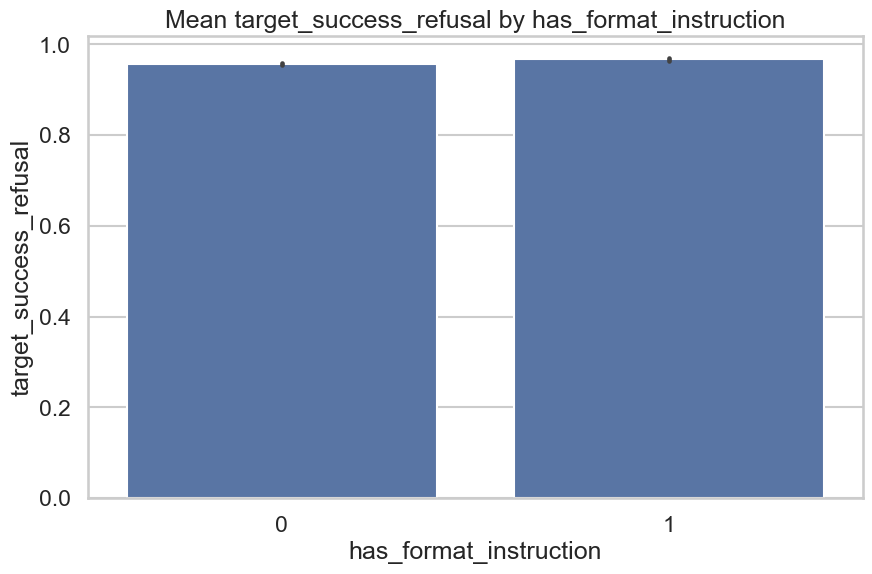

In [153]:
for col in ["has_role_instruction", "has_audience_or_level_instruction", "has_format_instruction"]:
    sns.barplot(data=df, x=col, y="target_success_refusal", estimator=np.mean)
    plt.title(f"Mean target_success_refusal by {col}")
    plt.show()

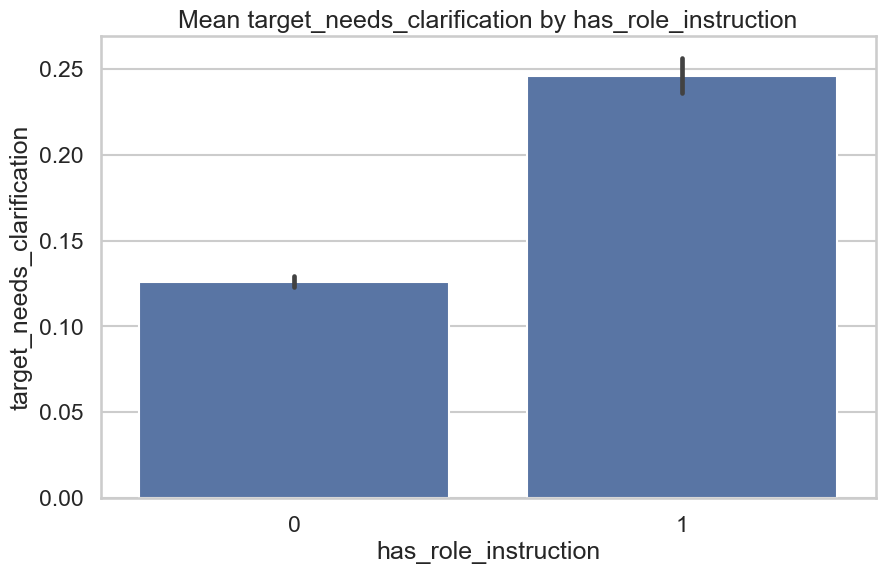

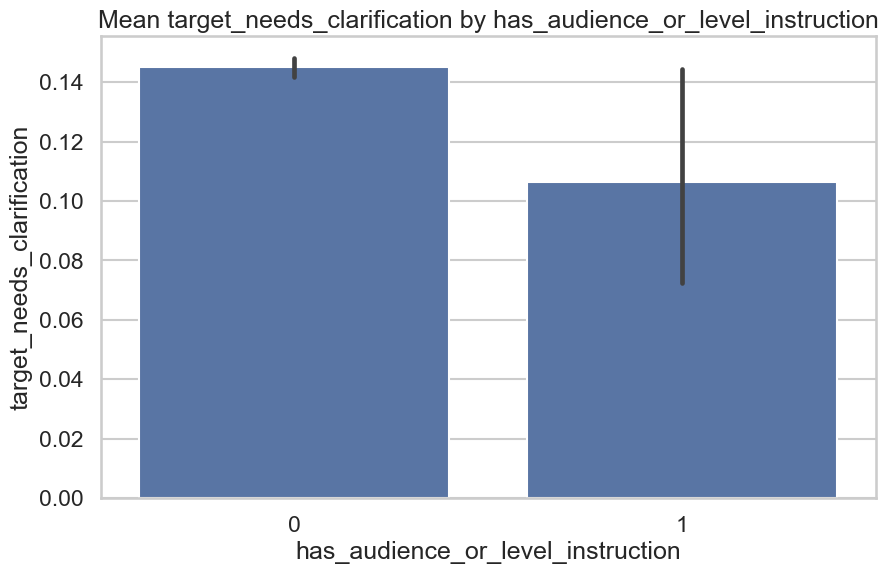

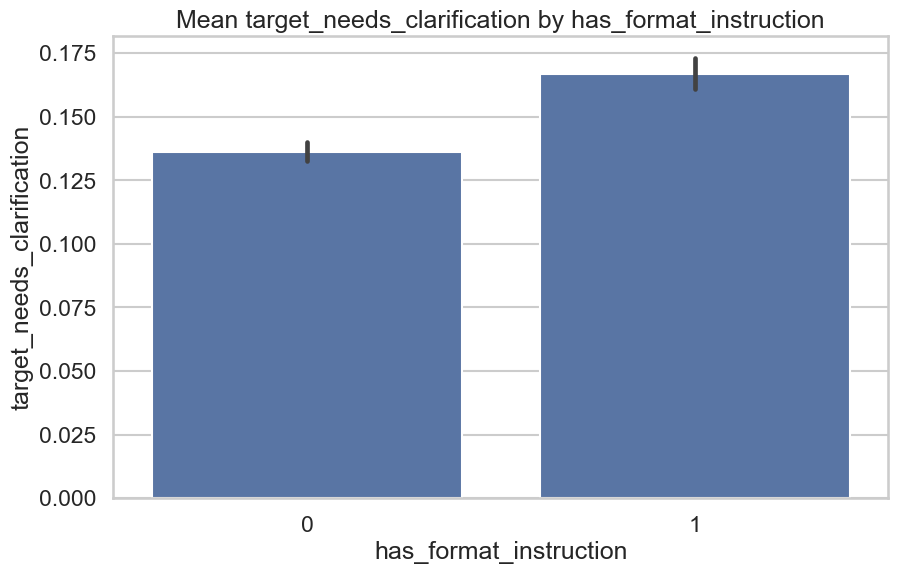

In [154]:
for col in ["has_role_instruction", "has_audience_or_level_instruction", "has_format_instruction"]:
    sns.barplot(data=df, x=col, y="target_needs_clarification", estimator=np.mean)
    plt.title(f"Mean target_needs_clarification by {col}")
    plt.show()

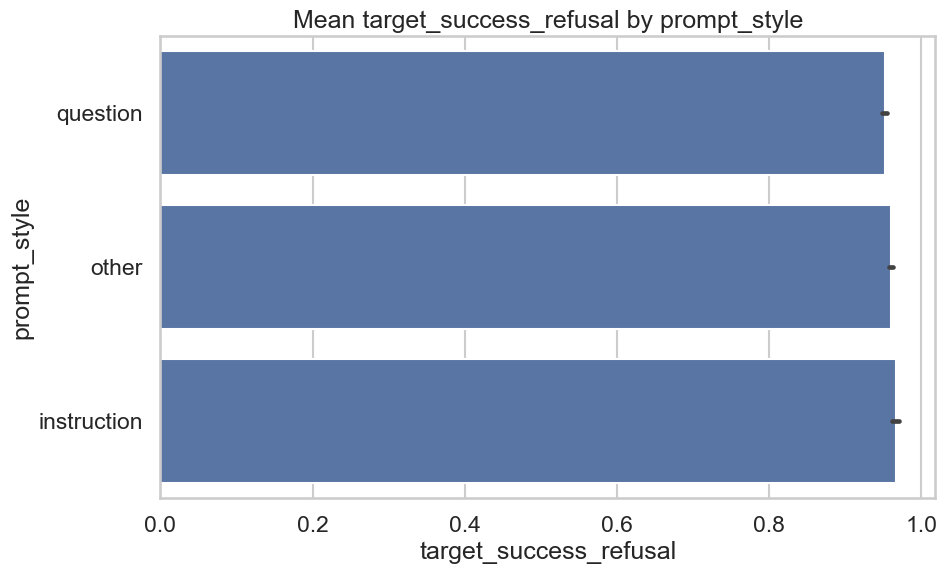

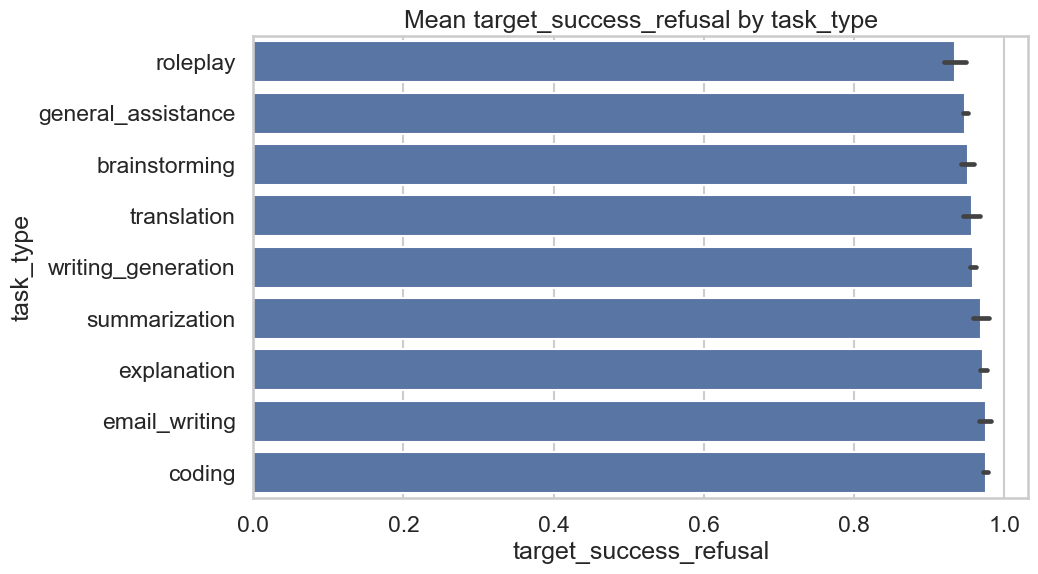

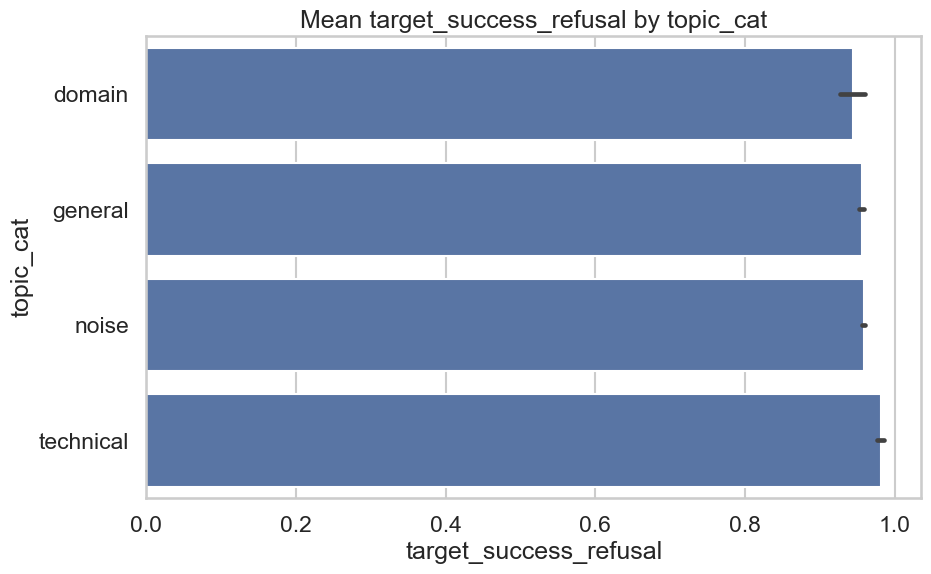

In [155]:
for col in ["prompt_style", "task_type", "topic_cat"]:
    order = df.groupby(col)["target_success_refusal"].mean().sort_values().index
    sns.barplot(data=df, y=col, x="target_success_refusal", order=order, estimator=np.mean)
    plt.title(f"Mean target_success_refusal by {col}")
    plt.show()

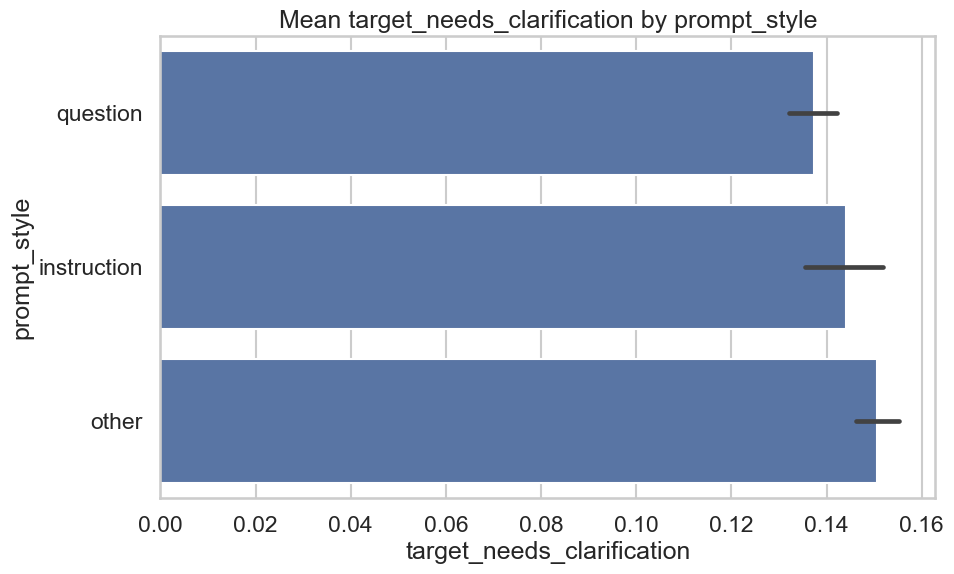

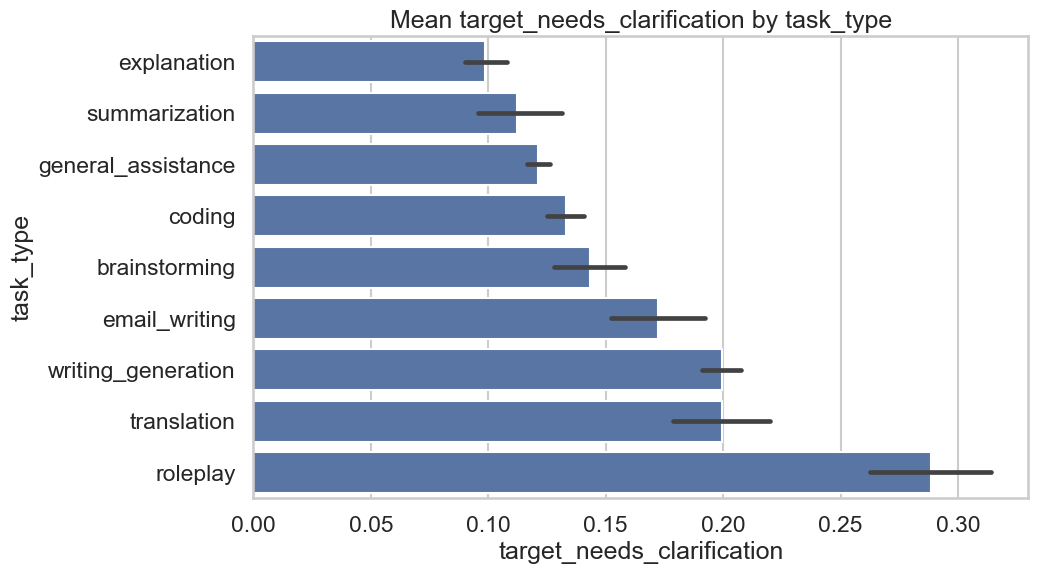

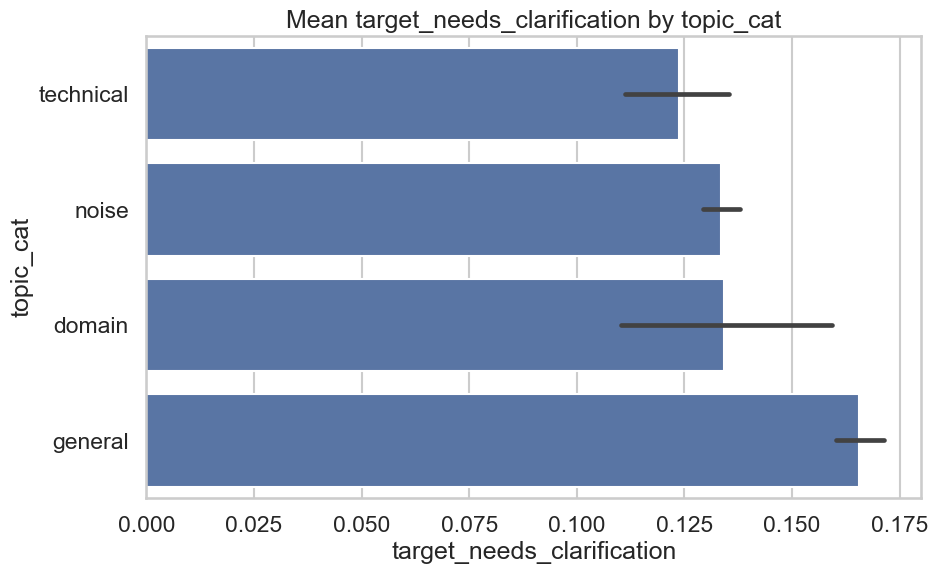

In [156]:
for col in ["prompt_style", "task_type", "topic_cat"]:
    order = df.groupby(col)["target_needs_clarification"].mean().sort_values().index
    sns.barplot(data=df, y=col, x="target_needs_clarification", order=order, estimator=np.mean)
    plt.title(f"Mean target_needs_clarification by {col}")
    plt.show()

In [157]:
pd.crosstab(df["prompt_style"], df["target_success_refusal"], normalize="index")

target_success_refusal,0,1
prompt_style,,
instruction,0.03,0.97
other,0.04,0.96
question,0.05,0.95


In [158]:
pd.crosstab(df["prompt_style"], df["target_needs_clarification"], normalize="index")

target_needs_clarification,0,1
prompt_style,,
instruction,0.86,0.14
other,0.85,0.15
question,0.86,0.14


## Topic Analysis

`topic_label` is a high-cardinality feature and is therefore analyzed separately. Instead of reviewing all categories, the notebook focuses on the most frequent topics and the long-tail structure.

In [159]:
# ----------------------------
# TOPIC LABEL ANALYSIS
# ----------------------------

topic_counts = df["topic_label"].value_counts()

print("Unique topics:", topic_counts.shape[0])
display(topic_counts.head(20))
print("Other topics:", topic_counts.iloc[20:].sum())

Unique topics: 25


topic_label
-1_like_use_data_write_time                         25249
0_write_like_chatgpt_want_use                       17294
1_const_react_gt_class_function                      1496
2_recipe_chicken_add_food_ingredients                 377
3_int_std_public_stream_return                        281
4_git_github_commit_repo_branch                       192
5_device_temperature_room_air_boolean                 174
6_circle_equation_point_radius_triangle               130
7_excel_column_sheet_cell_row                         118
8_resistance_weight_week_exercise_fitness             113
9_network_server_ip_ssh_windows                        97
10_files_file_directory_folder_ubuntu                  90
11_docker_container_feature_features_compose           87
12_signal_limited_ideal_mathematical_spectrum          74
13_binary_printf_compression_uid_php                   71
15_gpt_semantic_model_microsoft_like                   67
14_image_markdown_using code_block_code block          67
16

Other topics: 264


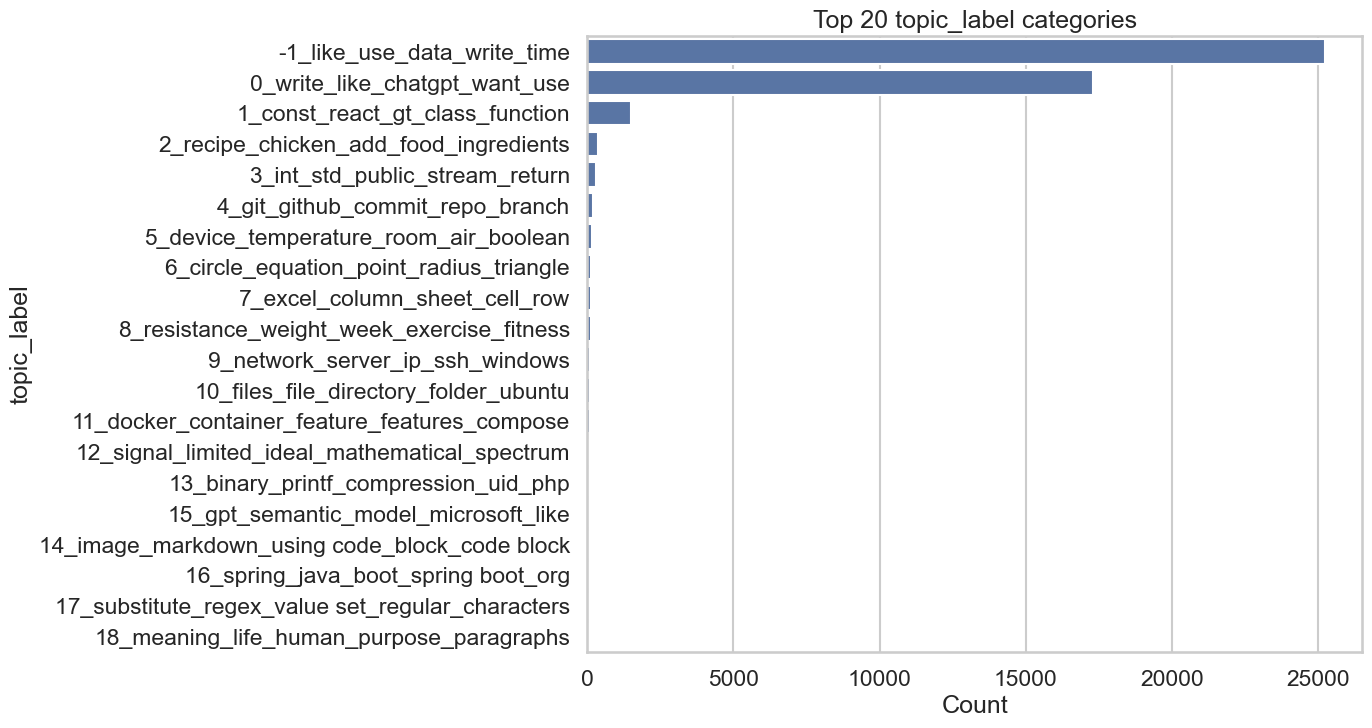

In [160]:
# ----------------------------
# TOP TOPICS PLOT
# ----------------------------

top_20_topics = topic_counts.head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_20_topics.values, y=top_20_topics.index)
plt.title("Top 20 topic_label categories")
plt.xlabel("Count")
plt.ylabel("topic_label")
plt.show()

## EDA Takeaways

This final section summarizes the main findings from the audit and the exploratory analysis. It should highlight important feature behaviors, modelling implications, class imbalances, skewed targets, and risks such as redundancy or outliers.

In [161]:
# ----------------------------
# EDA NOTES
# ----------------------------

eda_notes = [
    "Major skewness patterns in numeric features.",
    "Target_cost is strongly right-skewed.",
    "target_success_refusal and target_needs_clarification are imbalanced."]

for note in eda_notes:
    print("-", note)

- Major skewness patterns in numeric features.
- Target_cost is strongly right-skewed.
- target_success_refusal and target_needs_clarification are imbalanced.


In [162]:
df[["first_prompt", "orthographic_error_rate"]].sort_values(
    by="orthographic_error_rate",
    ascending=False
).head(40)


#len(df)

,first_prompt,orthographic_error_rate
38647,Please remember that Rhys has the following 4-star characters:\n\nYaoyao\n\nFaruzan\n\nLayla\n\nCandace\n\nDori\n\nC...,0.56
41571,Please remember that Rhys has the following 4-star characters:\n\nYaoyao\n\nFaruzan\n\nLayla\n\nCandace\n\nDori\n\nC...,0.56
21648,I have a JS script that outputs human readable statistics about the health of some orgs:\n\n var resellers = db.rese...,0.56
15270,I have a JS script that outputs human readable statistics about the health of some orgs:\n\n var resellers = db.rese...,0.56
22990,I have a JS script that outputs human readable statistics about the health of some orgs:\n\n var resellers = db.rese...,0.56
40043,"Can you please give me this in a list like this (""..."" OR ""...""):\n\nTextmetrics\tSpectrm\tFlowrite\tLengoo\tAcrolin...",0.56
31613,"Can you please give me this in a list like this (""..."" OR ""...""):\n\nTextmetrics\tSpectrm\tFlowrite\tLengoo\tAcrolin...",0.56
16874,"Can you give me the blow list in the following format (""..."" OR "".."")\n\nTextmetrics\nSpectrm\nFlowrite\nLengoo\nAcr...",0.55
36255,hvordan eksporterer jeg fra excel i sie4 format,0.50
29602,请详细地介绍一下这个项目：twbs/bootstrap,0.50


In [163]:
# ----------------------------
# SAVE DATA
# ----------------------------

save_csv(df, OUTPUT_PATH)

print("Shape:", df.shape)
print(f"Saved full dataframe: {OUTPUT_PATH}")


Shape: (46429, 31)
Saved full dataframe: c:\Users\heike\Desktop\Stackfuel\Portfolio\llm-sustainability-analysis\01_data\03_features\llm_sustainability_strict_v1-2-0_dataframe.csv
